# Dynamic Price Optimization — Retail Pricing Project

Data science portfolio project: analyze historical sales data to build a demand model, estimate price elasticity, and recommend prices that maximize expected **revenue** (cost data was not available, so profit maximization was replaced with revenue maximization — see note in the Optimization section).

**Pipeline:** SQL Extraction → Data Cleaning → EDA → Price↔Demand Analysis → Two-Part Demand Model → Elasticity → Pricing Simulation → Revenue Optimization


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading (SQL Server)

Connecting to the `retail_pricing` database and pulling a random sample (~100k rows) from `sales_raw`, casting raw columns to proper types (`date`, `float`) at the source.


In [2]:
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 17 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=retail_pricing;"
    "Trusted_Connection=yes;"
)

print("Connected successfully")

query = """
SELECT TOP (100000)
    product_id,
    store_id,
    TRY_CONVERT(date, date) AS date,
    TRY_CONVERT(float, price) AS price,
    TRY_CONVERT(float, sales) AS sales,
    TRY_CONVERT(float, stock) AS stock
    ,
    promo_bin_1
FROM sales_raw
WHERE ABS(CHECKSUM(product_id, store_id, date)) % 200 = 0
ORDER BY NEWID();
"""

df = pd.read_sql(query, conn)

Connected successfully


C:\Users\mahmo\AppData\Local\Temp\ipykernel_24764\1152267111.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## 2. Initial Data Inspection

Quick shape/dtype checks before any cleaning.


In [3]:
df.shape

(100000, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   product_id   100000 non-null  object 
 1   store_id     100000 non-null  object 
 2   date         100000 non-null  object 
 3   price        98171 non-null   float64
 4   sales        79315 non-null   float64
 5   stock        79315 non-null   float64
 6   promo_bin_1  13869 non-null   object 
dtypes: float64(3), object(4)
memory usage: 5.3+ MB


In [5]:
df["date"]=pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   product_id   100000 non-null  object        
 1   store_id     100000 non-null  object        
 2   date         100000 non-null  datetime64[ns]
 3   price        98171 non-null   float64       
 4   sales        79315 non-null   float64       
 5   stock        79315 non-null   float64       
 6   promo_bin_1  13869 non-null   object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 5.3+ MB


In [6]:
df.isnull().sum()

product_id         0
store_id           0
date               0
price           1829
sales          20685
stock          20685
promo_bin_1    86131
dtype: int64

## 3. Feature Engineering — Date Features

Extracting `year`, `month`, `day`, `day_of_week`, `quarter` from the date column for later use as model features and for time-based analysis.


In [7]:
df["year"]=df["date"].dt.year
df["month"]=df["date"].dt.month
df["day"]=df["date"].dt.day
df["day_of_week"]=df["date"].dt.day_of_week
df["quarter"]=df["date"].dt.quarter
df.head()

,product_id,store_id,date,price,sales,stock,promo_bin_1,year,month,day,day_of_week,quarter
0,P0716,S0050,2019-09-03,7.90,0.0,7.0,None,2019,9,3,1,3
1,P0665,S0137,2017-07-19,10.75,0.0,3.0,None,2017,7,19,2,3
2,P0457,S0048,2019-09-17,44.00,0.0,11.0,None,2019,9,17,1,3
3,P0437,S0112,2018-07-04,NaN,0.0,2.0,None,2018,7,4,2,3
4,P0485,S0031,2019-09-02,17.90,0.0,2.0,None,2019,9,2,0,3


In [8]:
df["day_of_week"].value_counts().sort_index()

day_of_week
0    15104
1    14585
2    13874
3    13866
4    13803
5    14085
6    14683
Name: count, dtype: int64

## 4. Missing Values — Diagnosis & Cleaning

`sales` and `stock` are checked together first: a crosstab shows they are missing **jointly** (not independently), which suggests these rows represent "no data recorded" rather than a true zero. They are dropped together rather than imputed. `price` nulls (~2.2%) are dropped separately.


In [9]:
df[df["sales"].isna()][["price", "sales", "stock"]].head(10)

,price,sales,stock
5,12.90,NaN,NaN
6,21.90,NaN,NaN
8,114.90,NaN,NaN
9,4.75,NaN,NaN
10,12.90,NaN,NaN
15,19.00,NaN,NaN
16,299.90,NaN,NaN
21,1.95,NaN,NaN
23,4.95,NaN,NaN
24,34.90,NaN,NaN


In [10]:
pd.crosstab(
    df["sales"].isna(),
    df["stock"].isna()
)

stock,False,True
sales,,
False,79315,0
True,0,20685


In [11]:
df = df.dropna(subset=["sales", "stock"])

In [12]:
df.isnull().sum()

product_id         0
store_id           0
date               0
price           1707
sales              0
stock              0
promo_bin_1    68903
year               0
month              0
day                0
day_of_week        0
quarter            0
dtype: int64

In [13]:
df["price"].isna().mean()*100

np.float64(2.1521780243333546)

In [14]:
df=df.dropna(subset=['price']).copy()

In [15]:
df.shape

(77608, 12)

## 5. Data Overview After Cleaning


In [16]:
df.describe()

,date,price,sales,stock,year,month,day,day_of_week,quarter
count,77608,77608.000000,77608.000000,77608.000000,77608.000000,77608.000000,77608.000000,77608.000000,77608.000000
mean,2018-11-04 08:54:30.466962432,16.725539,0.401110,15.553061,2018.326075,6.729512,15.712375,2.954708,2.731123
min,2017-07-01 00:00:00,0.010000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,1.000000
25%,2018-07-11 00:00:00,3.500000,0.000000,4.000000,2018.000000,2.000000,8.000000,1.000000,1.000000
50%,2019-01-08 00:00:00,8.500000,0.000000,8.000000,2019.000000,8.000000,16.000000,3.000000,3.000000
75%,2019-08-07 00:00:00,17.900000,0.000000,16.000000,2019.000000,9.000000,23.000000,5.000000,3.000000
max,2019-09-30 00:00:00,1599.000000,160.000000,3097.000000,2019.000000,10.000000,31.000000,6.000000,4.000000
std,NaN,38.766333,1.768883,36.463997,0.795444,3.242136,8.814990,2.026579,1.083725


### Sanity Check — Date Consistency

Confirming the extracted `month` column always matches the actual month in `date` (validates the date feature engineering above).


In [17]:
df.loc[df["month"] != df["date"].dt.month, ["date", "month"]].head(10)


,date,month


## 6. Sales Distribution Analysis


<Axes: xlabel='sales'>

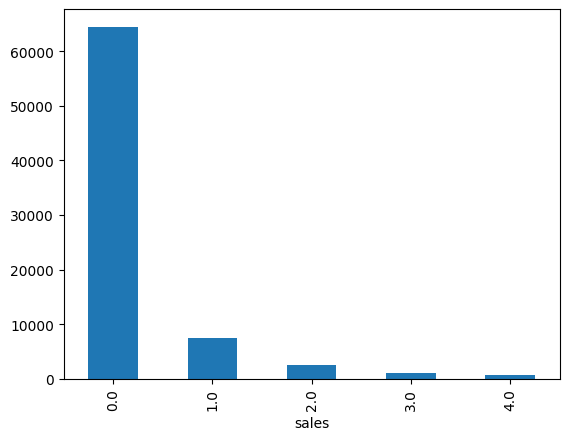

In [18]:
df["sales"].value_counts().head().plot(kind="bar")

### ⚠️ Outlier Detection on Price — Attempt 1 (Global IQR)

Computing IQR bounds on the whole `price` column, ignoring that different products have very different natural price ranges. This flags legitimately expensive products as "outliers." **Kept here for comparison** — see the corrected per-product version in section 13.


In [19]:
q1=df["price"].quantile(0.25)
q3=df["price"].quantile(0.75)
iqr= q3 -q1 
lower=q1-(1.5*iqr)
upper=q3+(1.5*iqr)
outliers=df[(df["price"]< lower)| (df["price"]>upper)]
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Outliers:", len(outliers))
print("Outlier percentage:", len(outliers) / len(df) * 100)

Q1: 3.5
Q3: 17.9
IQR: 14.399999999999999
Lower bound: -18.099999999999998
Upper bound: 39.5
Outliers: 6729
Outlier percentage: 8.670497886815792


In [20]:
df["sales"].describe()

count    77608.000000
mean         0.401110
std          1.768883
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        160.000000
Name: sales, dtype: float64

In [21]:
(df["sales"]==0).mean()*100

np.float64(83.0855066487991)

### Sales Distribution — Zero-Inflation Check

~83% of rows have `sales == 0`. This is a critical finding: demand here is **zero-inflated**, which is why the modeling approach later splits into two stages (probability of sale + quantity given a sale) instead of one plain regression.


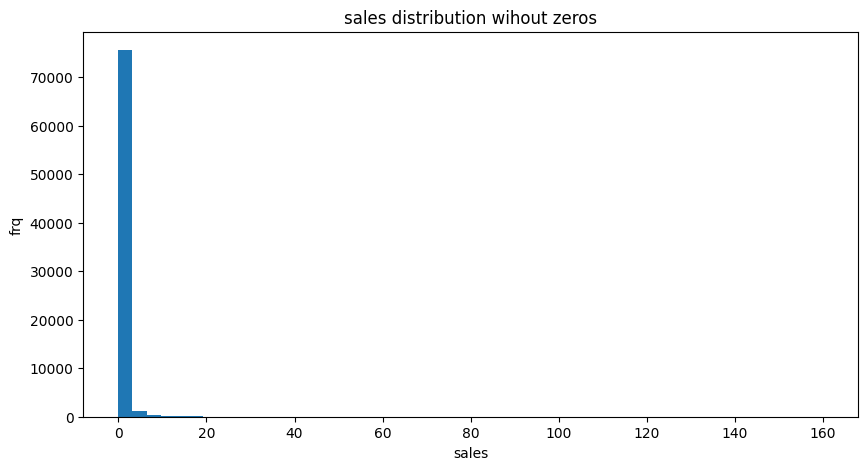

In [22]:
plt.figure(figsize=(10,5))
plt.hist(df["sales"],bins=50)
plt.title("sales distribution wihout zeros")
plt.xlabel("sales")
plt.ylabel("frq")
plt.show()

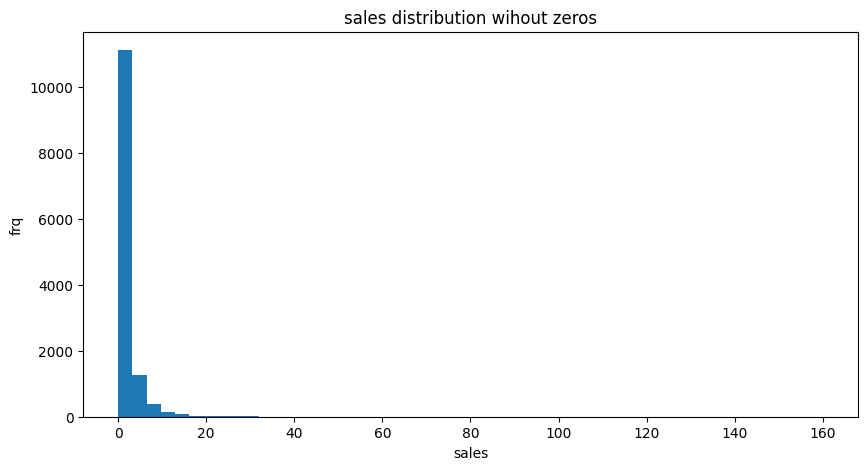

In [23]:
plt.figure(figsize=(10,5))
plt.hist(df[df["sales"] > 0]["sales"], bins=50)
plt.title("sales distribution wihout zeros")
plt.xlabel("sales")
plt.ylabel("frq")
plt.show()

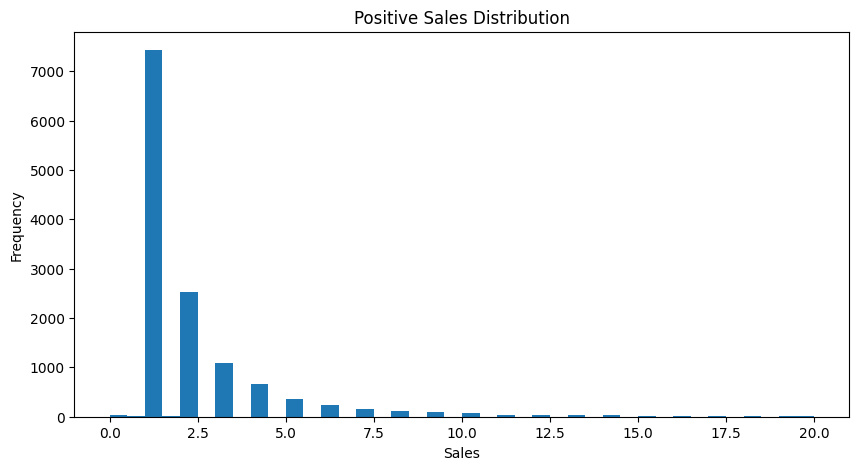

In [24]:
positive_sales = df.loc[df["sales"] > 0, "sales"]

plt.figure(figsize=(10,5))
plt.hist(positive_sales, bins=40, range=(0,20))

plt.title("Positive Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

## 7. Stock Analysis


In [25]:
df["stock"].describe()

count    77608.000000
mean        15.553061
std         36.463997
min          0.000000
25%          4.000000
50%          8.000000
75%         16.000000
max       3097.000000
Name: stock, dtype: float64

### ⚠️ Outlier Detection on Stock — Global IQR

Same global-IQR approach as price above; kept as-is since stock ranges are more homogeneous than price, but worth revisiting per-product if needed later.


In [26]:
q1=df["stock"].quantile(0.25)
q3=df["stock"].quantile(0.75)
iqr= q3 -q1 
lower=q1-(1.5*iqr)
upper=q3+(1.5*iqr)
outliers=df[(df["stock"]< lower)| (df["stock"]>upper)]
print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Outliers:", len(outliers))
print("Outlier percentage:", len(outliers) / len(df) * 100)

Q1: 4.0
Q3: 16.0
IQR: 12.0
Lower bound: -14.0
Upper bound: 34.0
Outliers: 6533
Outlier percentage: 8.417946603442944


## 8. Sales Patterns Over Time

Average sales by month, year, and day of week — checking for seasonality or weekly patterns.


<Axes: xlabel='month'>

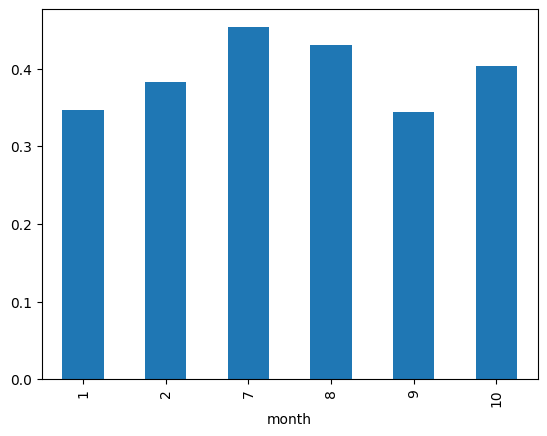

In [27]:
df.groupby("month")["sales"].mean().plot(kind="bar")

<Axes: xlabel='year'>

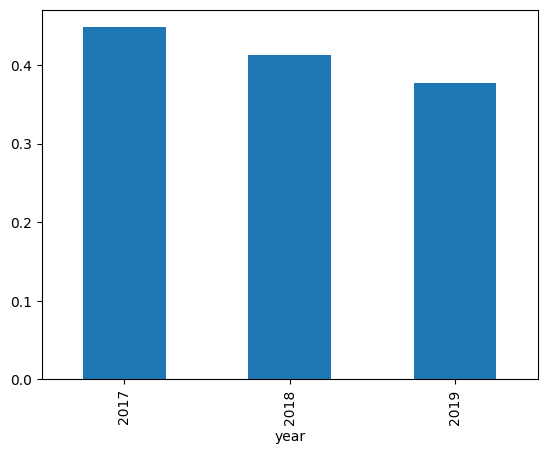

In [28]:
df.groupby("year")["sales"].mean().plot(kind="bar")

<Axes: xlabel='day_of_week'>

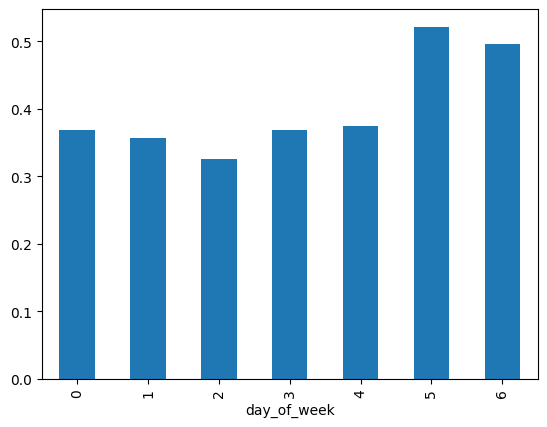

In [29]:
df.groupby("day_of_week")["sales"].mean().plot(kind="bar")

## 9. Price vs Sales — Overall Relationship

Scatter plot and raw correlation between `price` and `sales` (positive-sales rows only). The overall correlation is weak, which motivates the group-level analysis below.


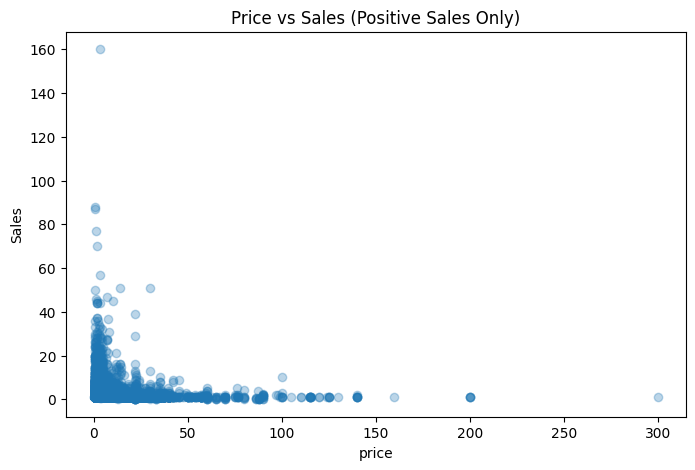

In [30]:
positive_sales=df[df["sales"]>0]
plt.figure(figsize=(8.,5))
plt.scatter(
        positive_sales["price"],
        positive_sales["sales"],
        alpha=0.3

)
plt.xlabel("price")
plt.ylabel("Sales")
plt.title("Price vs Sales (Positive Sales Only)")

plt.show()

In [31]:
positive_sales[["price","sales"]].corr()

,price,sales
price,1.000000,-0.104756
sales,-0.104756,1.000000


## 10. Price vs Sales — Controlling for Product/Store (Within-Group Correlation)

The raw correlation above is weak partly because it mixes many different products and stores together. Computing the correlation **within each product-store group** removes that confound. First attempt in pandas (below), then repeated in SQL directly for the full dataset (more reliable, avoids pandas grouping issues on this data volume).


In [32]:
corr_by_product_store=(
    df.groupby(['product_id',"store_id"])
    .filter(lambda x : len(x)>=30)
    .groupby(["product_id","store_id"])[["price","sales"]]
    .corr()
    .iloc[0::2, -1]
      .reset_index(name="price_sales_corr")
)

In [33]:
corr_by_product_store.head()

,product_id,store_id,price_sales_corr


### Same Analysis via SQL (full dataset, more robust)


In [34]:
query_corr = """
WITH clean_data AS (
    SELECT
        product_id,
        store_id,
        TRY_CONVERT(float, price) AS price,
        TRY_CONVERT(float, sales) AS sales
    FROM sales_raw
    WHERE TRY_CONVERT(float, price) IS NOT NULL
      AND TRY_CONVERT(float, sales) IS NOT NULL
      AND TRY_CONVERT(float, stock) > 0
      AND promo_bin_1 IS NULL
),

group_avg AS (
    SELECT
        product_id,
        store_id,
        COUNT(*) AS n,
        AVG(price) AS avg_price,
        AVG(sales) AS avg_sales
    FROM clean_data
    GROUP BY product_id, store_id
    HAVING COUNT(*) >= 30
),

centered AS (
    SELECT
        d.product_id,
        d.store_id,
        g.n,
        (d.price - g.avg_price) AS price_dev,
        (d.sales - g.avg_sales) AS sales_dev
    FROM clean_data d
    JOIN group_avg g
        ON d.product_id = g.product_id
       AND d.store_id = g.store_id
),

corr_stats AS (
    SELECT
        product_id,
        store_id,
        n,
        SUM(price_dev * sales_dev) AS covariance_part,
        SUM(price_dev * price_dev) AS price_var_part,
        SUM(sales_dev * sales_dev) AS sales_var_part
    FROM centered
    GROUP BY product_id, store_id, n
)

SELECT
    product_id,
    store_id,
    n,
    covariance_part /
    NULLIF(
        SQRT(price_var_part * sales_var_part),
        0
    ) AS price_sales_corr
FROM corr_stats;
"""

corr_df = pd.read_sql(query_corr, conn)

C:\Users\mahmo\AppData\Local\Temp\ipykernel_24764\1560742037.py:64: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  corr_df = pd.read_sql(query_corr, conn)


In [35]:
corr_df.head()

,product_id,store_id,n,price_sales_corr
0,P0499,S0141,1003,-4.454951e-02
1,P0054,S0023,941,2.653903e-02
2,P0116,S0101,557,4.698322e-17
3,P0504,S0102,790,-6.460739e-02
4,P0055,S0007,185,3.641013e-02


In [36]:
corr_df['price_sales_corr'].describe()

count    27988.000000
mean        -0.029888
std          0.104451
min         -1.000000
25%         -0.078241
50%         -0.016881
75%          0.018435
max          0.767948
Name: price_sales_corr, dtype: float64

In [37]:
(corr_df["price_sales_corr"] < 0).mean() * 100

np.float64(53.789450862576274)

## 11. Price Outlier Detection — Corrected (Per-Product IQR)

Fixing the issue from section 6: computing IQR bounds **per `product_id`** instead of globally, so each product is judged against its own typical price range. Outliers are flagged (`price_outliers` column) but not removed — some may be promotions rather than data errors.


In [38]:
Q1= df.groupby("product_id")["price"].transform("quantile",0.25)
Q3=df.groupby("product_id")["price"].transform("quantile",0.75)
IQR=Q3-Q1
LOWER=Q1-(1.5*IQR)
UPPER=Q3+(1.5*IQR)
df["price_outliers"]=((df["price"]>UPPER) |( df["price"]<LOWER))
print(df["price_outliers"].sum())
print(df["price_outliers"].mean()*100)

2306
2.9713431604989173


In [39]:
df[df["price_outliers"]][["product_id","store_id","date","price","sales","stock"]].sort_values("price",ascending=False).head(20)

,product_id,store_id,date,price,sales,stock
2192,P0474,S0115,2018-07-13,699.0,0.0,2.0
72437,P0474,S0102,2018-07-10,699.0,0.0,2.0
53601,P0474,S0115,2018-07-12,699.0,0.0,2.0
16415,P0474,S0102,2018-07-04,699.0,0.0,2.0
8216,P0474,S0115,2018-07-16,699.0,0.0,2.0
48625,P0474,S0104,2018-07-02,699.0,0.0,3.0
29707,P0474,S0002,2018-07-14,699.0,0.0,2.0
42559,P0474,S0104,2018-07-03,699.0,0.0,3.0
2239,P0632,S0085,2019-08-22,579.0,0.0,1.0
23045,P0474,S0063,2018-07-26,499.0,0.0,2.0


## 12. Stock Level vs Sales Rate

Bucketing stock into ranges to see how stock availability relates to the probability and volume of sales.


In [40]:
bins=[-1,0,2,5,10,20,50,float("inf")]
labels=["0","1-2",'3-5',"6-10",'11-20',"21-50","51+"]
df["stock_group"]=pd.cut(
    df["stock"],bins=bins,labels=labels
)
stock_analysis=df.groupby("stock_group",observed=True).agg(
    rows=("sales","size"),
    sales_rate=("sales",lambda x : (x>0).mean()*100),
    avg_sales=("sales","mean")

)
stock_analysis

,rows,sales_rate,avg_sales
stock_group,,,
0,575,100.000000,2.686597
1-2,10440,8.754789,0.147771
3-5,15996,9.727432,0.155320
6-10,18901,11.819480,0.203813
11-20,17118,17.829186,0.342662
21-50,11132,27.614086,0.674697
51+,3446,49.970981,2.416892


## 13. Promotion Impact

Comparing sales rate and average sales across `promo_bin_1` groups.


In [41]:
promotion_analysis=df.groupby("promo_bin_1",observed=True).agg(
rows=("sales","size"),
sales_rate=("sales",lambda x : (x>0).mean()*100),
avg_sales=("sales","mean")
)
promotion_analysis

,rows,sales_rate,avg_sales
promo_bin_1,,,
high,1396,21.418338,0.624642
low,2192,20.437956,0.445929
moderate,1168,11.815068,0.195205
veryhigh,1153,23.764094,0.647008
verylow,4438,22.870662,0.616719


In [42]:
df.columns

Index(['product_id', 'store_id', 'date', 'price', 'sales', 'stock',
       'promo_bin_1', 'year', 'month', 'day', 'day_of_week', 'quarter',
       'price_outliers', 'stock_group'],
      dtype='object')

## 14. Store-Level Performance

Top and bottom performing stores by average sales.


In [43]:


store_analysis=df.groupby("store_id",observed=True).agg(
    rows=("sales","size"),
    sales_rate=("sales",lambda x :(x>0).mean()*100 ),
    sales_avg=("sales","mean")
)
store_analysis.sort_values("sales_avg",ascending=False).head(10)

,rows,sales_rate,sales_avg
store_id,,,
S0085,1381,27.299059,1.265971
S0080,298,36.912752,1.134228
S0062,1070,27.943925,1.013393
S0075,233,27.896996,0.858369
S0084,554,26.895307,0.857247
S0076,160,33.125000,0.775000
S0095,788,28.299492,0.761299
S0100,66,33.333333,0.742424
S0020,1131,25.022104,0.681366


In [44]:
store_analysis.sort_values("sales_avg").head(10)

,rows,sales_rate,sales_avg
store_id,,,
S0057,121,6.611570,0.082645
S0090,597,5.695142,0.088777
S0078,655,8.244275,0.111450
S0120,312,13.141026,0.157051
S0050,811,10.727497,0.162491
S0089,257,9.727626,0.163424
S0130,301,10.299003,0.172757
S0083,646,10.216718,0.174923
S0063,599,11.853088,0.176962


## 15. Product-Level Performance

Top and bottom performing products by average sales.


In [45]:
product_analysis = (
    df.groupby("product_id")
      .agg(
          rows=("sales", "size"),
          sale_rate=("sales", lambda x: (x > 0).mean() * 100),
          avg_sales=("sales", "mean")
      )
      .reset_index()
)

top_products = (
    product_analysis
    .sort_values("avg_sales", ascending=False)
    .head(10)
)

bottom_products = (
    product_analysis
    .sort_values("avg_sales", ascending=True)
    .head(10)
)

top_products, bottom_products

(    product_id  rows   sale_rate  avg_sales
 308      P0388   150   76.000000   6.453333
 348      P0438   272   60.294118   5.356618
 83       P0103   517   89.361702   5.338491
 394      P0494     1  100.000000   4.000000
 327      P0413    97   50.515464   3.335454
 454      P0563    29   51.724138   3.137931
 427      P0531   129   48.837209   3.131783
 575      P0709   145   58.620690   2.324138
 497      P0621    38   60.526316   2.289474
 450      P0557    20   60.000000   2.250000,
     product_id  rows  sale_rate  avg_sales
 59       P0075    31        0.0        0.0
 57       P0072    10        0.0        0.0
 51       P0065     9        0.0        0.0
 19       P0025    35        0.0        0.0
 17       P0022    20        0.0        0.0
 16       P0021    12        0.0        0.0
 426      P0529    18        0.0        0.0
 423      P0526     7        0.0        0.0
 37       P0048    21        0.0        0.0
 601      P0746    10        0.0        0.0)

## 16. Demand Model — Stage 1: Probability of Sale (Classification)

Given the zero-inflation found in section 6, demand is modeled in two parts. **Stage 1** predicts whether a sale happens at all (`sale_flag = sales > 0`) using Logistic Regression.


In [46]:


from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [47]:
df["date"] = pd.to_datetime(df["date"])

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["quarter"] = df["date"].dt.quarter

In [48]:
df = df.sort_values("date").copy()

In [49]:
df["sale_flag"]=(df["sales"]>0).astype(int)
print(df["date"].min(),"->",df["date"].max())

print(df.groupby(df["date"].dt.to_period("M")).size())


2017-07-01 00:00:00 -> 2019-09-30 00:00:00
date
2017-07     8172
2017-10     7853
2018-07     9764
2018-10    10488
2019-01    10265
2019-02     9339
2019-08    11184
2019-09    10543
Freq: M, dtype: int64


### Train/Test Split (Time-Based)

Splitting by date (80th percentile of dates in the sample) rather than randomly, since this is a forecasting problem — the model should be evaluated on data that comes chronologically after what it was trained on.


In [50]:
features = ["price", "stock", "promo_bin_1", "product_id", "store_id",
            "year", "month", "day_of_week", "quarter"]




cutoff_date = df["date"].quantile(0.8)
print("Cutoff date:", cutoff_date)

train_mask = df["date"] < cutoff_date
test_mask  = df["date"] >= cutoff_date

x_train = df.loc[train_mask, features]
x_test  = df.loc[test_mask, features]
y_train = df.loc[train_mask, "sale_flag"]
y_test  = df.loc[test_mask, "sale_flag"]

print(x_train.shape, x_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

Cutoff date: 2019-08-17 00:00:00
(61697, 9) (15911, 9)
sale_flag
0    51106
1    10591
Name: count, dtype: int64
sale_flag
0    13375
1     2536
Name: count, dtype: int64


### Preprocessing

Numeric features are standardized; categorical features (`product_id`, `store_id`, `promo_bin_1`) are one-hot encoded with `handle_unknown="ignore"` so unseen categories in the test set (e.g. products that first appear after the cutoff date) don't break `.transform()`.


In [51]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_features = ["price", "stock", "year", "month", "day_of_week", "quarter"]
categorical_features = ["promo_bin_1", "product_id", "store_id"]

preprocessing=ColumnTransformer(
    [("num",StandardScaler(),numeric_features),
     ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)


    ]
)
x_train_preprocesed=preprocessing.fit_transform(x_train)
x_test_preprocessed=preprocessing.transform(x_test)
print(x_train_preprocesed.shape)
print(x_test_preprocessed.shape)

(61697, 737)
(15911, 737)


### Model Training & Evaluation

`class_weight="balanced"` is used because only ~17% of rows have `sale_flag = 1` — without it the model would default to predicting "no sale" almost always.


In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
model_1=LogisticRegression(class_weight="balanced",max_iter=1000)
model_1.fit(x_train_preprocesed,y_train)
y_pred=model_1.predict(x_test_preprocessed)
y_proba=model_1.predict_proba(x_test_preprocessed)[:,1]
print(classification_report(y_test,y_pred))
print("roc_auc_score",roc_auc_score(y_test,y_proba))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.94      0.77      0.84     13375
           1       0.37      0.72      0.49      2536

    accuracy                           0.76     15911
   macro avg       0.65      0.74      0.67     15911
weighted avg       0.85      0.76      0.79     15911

roc_auc_score 0.8180118665054983
[[10244  3131]
 [  705  1831]]


### Feature Importance — Model Coefficients

**Finding:** the top coefficients by magnitude are almost entirely `product_id` dummy variables — `price` does not appear near the top (checked explicitly below). This means the classifier is mostly learning "which product is this" rather than "how does price affect the odds of a sale." This is a known limitation, documented here rather than hidden — it's addressed later by adding `log_price` explicitly in the refined demand model (section 23).


In [53]:
featuer_names=preprocessing.get_feature_names_out()
cofficent=model_1.coef_[0]
coef_data_frame=pd.DataFrame(
 {
     "features":featuer_names,
     "coefecient":cofficent
 }   
).sort_values("coefecient",key=abs,ascending=False)
coef_data_frame.head(20)

,features,coefecient
92,cat__product_id_P0103,4.262952
253,cat__product_id_P0316,4.259537
438,cat__product_id_P0550,3.659666
309,cat__product_id_P0388,3.499631
448,cat__product_id_P0561,3.411388
482,cat__product_id_P0610,3.246229
292,cat__product_id_P0364,3.035527
453,cat__product_id_P0569,3.011848
152,cat__product_id_P0182,2.956835
267,cat__product_id_P0333,2.906776


In [54]:
coef_data_frame[coef_data_frame["features"] == "num__price"]

,features,coefecient
0,num__price,-0.629152


In [55]:
coef_df_sorted = coef_data_frame.reset_index(drop=True)
price_rank = coef_df_sorted[coef_df_sorted["features"] == "num__price"].index[0]
print(f"price ranked {price_rank + 1} out of {len(coef_df_sorted)}")

price ranked 346 out of 737


## 17. Demand Model — Stage 2: Quantity Given Sale (Regression)

**Stage 2** predicts the sale quantity, trained only on rows where `sales > 0` (the zero rows are handled entirely by Stage 1). Same time-based split and feature set as Stage 1.


In [56]:
train_r=df.loc[train_mask & (df["sales"]>0)]
test_r=df.loc[test_mask &( df["sales"]>0)]
x_train_r=train_r[features]
x_test_r=test_r[features]
y_train_r=train_r["sales"]
y_test_r=test_r["sales"]


preprocessor_r=ColumnTransformer(
    [
        ("num",StandardScaler(),numeric_features,),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)
x_train_preprocessor_r_train=preprocessor_r.fit_transform(x_train_r)
x_test_preprocessor_r_test=preprocessor_r.transform(x_test_r)


In [57]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model_2=LinearRegression()
model_2.fit(x_train_preprocessor_r_train,y_train_r)
y_pred_r=model_2.predict(x_test_preprocessor_r_test)
print("MAE",mean_absolute_error(y_test_r,y_pred_r))
print("r2_score",r2_score(y_test_r,y_pred_r))
print("MSE",mean_squared_error(y_test_r,y_pred_r))


MAE 1.5754291954906219
r2_score 0.20671653648244792
MSE 9.730686679880494


### Attempt 2 — Log-Transformed Target

Sales are right-skewed even after removing zeros, so a `log1p` transform is tried to reduce the influence of large outliers. Predictions are converted back with `expm1` before computing metrics, so they're comparable to the other models.


In [58]:
y_train_log_r=np.log1p(y_train_r)
y_test_log_r=np.log1p(y_test_r)
import numpy as np

y_train_log = np.log1p(y_train_r)
y_test_log = np.log1p(y_test_r)

reg_model_log = LinearRegression()
reg_model_log.fit(x_train_preprocessor_r_train, y_train_log)

y_pred_log = reg_model_log.predict(x_test_preprocessor_r_test)
y_pred_log_actual = np.expm1(y_pred_log)   # نرجعها لمقياسها الأصلي عشان نقارن صح

print("MAE:", mean_absolute_error(y_test_r, y_pred_log_actual))
print("RMSE:", mean_squared_error(y_test_r, y_pred_log_actual) ** 0.5)
print("R²:", r2_score(y_test_r, y_pred_log_actual))

MAE: 1.2971359738996364
RMSE: 3.1293629203309985
R²: 0.20164366270978884


### Attempt 3 — Random Forest (Non-Linear)

Testing whether a non-linear model captures more signal than plain Linear Regression.


In [59]:
from sklearn.ensemble import RandomForestRegressor
model_3=RandomForestRegressor(
    n_estimators=200,max_depth=10,n_jobs=1,random_state=42
)
model_3.fit(x_train_preprocessor_r_train, y_train_r)

y_pred_rf = model_3.predict(x_test_preprocessor_r_test)

print("MAE:", mean_absolute_error(y_test_r, y_pred_rf))
print("RMSE:", mean_squared_error(y_test_r, y_pred_rf) ** 0.5)
print("R²:", r2_score(y_test_r, y_pred_rf))

MAE: 1.3399623900073203
RMSE: 3.0510479842893954
R²: 0.24110273405653404


### Attempt 4 — HistGradientBoosting (Best Performer)

**Model comparison summary (R² on test set):**
| Model | MAE | RMSE | R² |
|---|---|---|---|
| Linear (raw) | 1.617 | 2.957 | 0.193 |
| Linear + log-transform | 1.298 | 3.100 | 0.113 |
| Random Forest | 1.327 | 2.959 | 0.192 |
| **HistGradientBoosting** | 1.406 | **2.880** | **0.235** |

HistGB wins on 2 of 3 metrics (RMSE, R²) and is selected as the Stage 2 model going forward. **Honest note:** R² ≈ 0.235 means the available features explain only about a quarter of the variance in sale quantity — this is documented as a known limitation of the current feature set (adding features like `price_relative_to_product_avg` or rolling sales averages would likely help more than trying further algorithms, since Random Forest already showed that added model complexity alone doesn't help).


In [60]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    max_depth=10,
    random_state=42
)
hgb_model.fit(x_train_preprocessor_r_train.toarray(), y_train_r)

y_pred_hgb = hgb_model.predict(x_test_preprocessor_r_test.toarray())

print("MAE:", mean_absolute_error(y_test_r, y_pred_hgb))
print("RMSE:", mean_squared_error(y_test_r, y_pred_hgb) ** 0.5)
print("R²:", r2_score(y_test_r, y_pred_hgb))

MAE: 1.3787660561900232
RMSE: 3.0838137458422996
R²: 0.22471533771057917


## 18. Combining Stage 1 & Stage 2 — Two-Part (Hurdle) Demand Model

`expected_demand = P(sale=1) × E(quantity | sale=1)` — multiplying the Stage 1 probability by the Stage 2 predicted quantity gives one unified expected-demand estimate for any row, even ones that rarely sell.


In [63]:
p_sale = model_1.predict_proba(x_test_preprocessed)[:, 1]

x_test_r_all_preprocessed = preprocessor_r.transform(x_test)

pred_sales = hgb_model.predict(
    x_test_r_all_preprocessed.toarray()
)

expected_demand = p_sale * pred_sales

print(expected_demand[:10])

[0.20890899 0.14585677 1.10449795 2.87163814 0.14144343 0.34755763
 0.05457212 0.86739698 0.15810884 0.73745749]


## 19. Price Elasticity — Per-Product (Log-Log Regression)

For each product, fitting `log(sales) ~ log(price)` and taking the slope as that product's price elasticity of demand — a quick, classical way to get an elasticity estimate directly from the historical data (independent of the ML models above).


In [68]:
# price elasticity

elasticity_df = df[
    (df["sales"] > 0) &
    (df["price"] > 0)
].copy()

elasticity_df["log_price"] = np.log(elasticity_df["price"])
elasticity_df["log_sales"] = np.log(elasticity_df["sales"])
def calculate_elasticity(x):
    if x["price"].nunique() < 2:
        return np.nan

    return np.polyfit(
        x["log_price"],
        x["log_sales"],
        1
    )[0]

elasticity = (
    elasticity_df
    .groupby("product_id")
    .apply(calculate_elasticity)
    .reset_index(name="price_elasticity")
)
elasticity.head(10)

C:\Users\mahmo\AppData\Local\Temp\ipykernel_24764\2455250794.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(calculate_elasticity)


,product_id,price_elasticity
0,P0001,NaN
1,P0004,NaN
2,P0005,0.000000
3,P0007,0.000000
4,P0008,0.000000
5,P0009,NaN
6,P0012,NaN
7,P0015,-0.294929
8,P0016,NaN
9,P0017,-0.393029


## 20. Pricing Simulation — Single Product (Initial Attempt)

Using the two-part model as a simulator: hold everything about a scenario (product, store, date context) fixed, vary only `price` across its observed range, and read off expected demand and revenue at each price point.


In [70]:
product = "P0017"
product_data=df[df["product_id"]==product].copy()

senario=product_data.iloc[0].copy()
min_price=product_data["price"].quantile(0.10)
max_price=product_data["price"].quantile(0.90)
prices=np.linspace(min_price,max_price,20)
simulation = pd.DataFrame({
    "price": prices
})

simulation["stock"] = senario["stock"]
simulation["promo_bin_1"] = senario["promo_bin_1"]
simulation["product_id"] = senario["product_id"]
simulation["store_id"] = senario["store_id"]
simulation["year"] = senario["year"]
simulation["month"] = senario["month"]
simulation["day_of_week"] = senario["day_of_week"]
simulation["quarter"] = senario["quarter"]

x_sim_class=simulation[features]
x_sim_processed=preprocessing.transform(x_sim_class)
p_sim=model_1.predict_proba(x_sim_processed)[:,1]

x_sim_r=preprocessor_r.transform(simulation[features])
predict_sim_r=hgb_model.predict(x_sim_r.toarray())

# expected demand
simulation["p_sale"] = p_sim
simulation["pred_sales"] = predict_sim_r
simulation["expected_demand"] = (
    simulation["p_sale"] * simulation["pred_sales"]
)
# expected revenue
simulation["expected_revenue"] = (
    simulation["price"] * simulation["expected_demand"]
)
# best price
best_price = simulation.loc[
    simulation["expected_revenue"].idxmax()
]
print(best_price)

price                   2.95
stock                   20.0
promo_bin_1         veryhigh
product_id             P0017
store_id               S0091
year                    2017
month                      7
day_of_week                5
quarter                    3
p_sale              0.897867
pred_sales          1.981116
expected_demand     1.778779
expected_revenue    5.247399
Name: 19, dtype: object


In [71]:
simulation[["price", "p_sale", "pred_sales",
            "expected_demand", "expected_revenue"]]

,price,p_sale,pred_sales,expected_demand,expected_revenue
0,1.450000,0.900430,2.141946,1.928674,2.796577
1,1.528947,0.900297,2.074499,1.867665,2.855561
2,1.607895,0.900163,2.074499,1.867388,3.002563
3,1.686842,0.900030,2.074499,1.867110,3.149520
4,1.765789,0.899896,2.074499,1.866832,3.296433
5,1.844737,0.899762,2.074499,1.866554,3.443301
6,1.923684,0.899627,2.074499,1.866276,3.590125
7,2.002632,0.899493,1.981116,1.782000,3.568689
8,2.081579,0.899358,1.981116,1.781733,3.708818
9,2.160526,0.899224,1.981116,1.781466,3.848904


## 21. Refined Demand Model — Adding `log_price` as an Explicit Feature

Addressing the finding from section 16 (price was barely used by the classifier): retraining Stage 2 with `log_price` instead of raw `price`, so the simulation below responds more directly to price changes rather than being dominated by product identity.


In [72]:


from sklearn.ensemble import GradientBoostingRegressor





train_r = df.loc[
    train_mask & (df["sales"] > 0)
].copy()

test_r = df.loc[
    test_mask & (df["sales"] > 0)
].copy()


train_r["log_price"] = np.log(train_r["price"])
test_r["log_price"] = np.log(test_r["price"])


demand_features = [
    "log_price",
    "stock",
    "promo_bin_1",
    "product_id",
    "store_id",
    "year",
    "month",
    "day_of_week",
    "quarter"
]

numeric_features_demand = [
    "log_price",
    "stock",
    "year",
    "month",
    "day_of_week",
    "quarter"
]

categorical_features_demand = [
    "promo_bin_1",
    "product_id",
    "store_id"
]


demand_preprocessor = ColumnTransformer(
    [
        (
            "num",
            StandardScaler(),
            numeric_features_demand
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_demand
        )
    ]
)


x_train_demand = train_r[demand_features]
y_train_demand = train_r["sales"]

x_test_demand = test_r[demand_features]
y_test_demand = test_r["sales"]


x_train_demand_processed = demand_preprocessor.fit_transform(
    x_train_demand
)

x_test_demand_processed = demand_preprocessor.transform(
    x_test_demand
)


demand_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

demand_model.fit(
    x_train_demand_processed.toarray(),
    y_train_demand
)


y_pred_demand = demand_model.predict(
    x_test_demand_processed.toarray()
)

mae = mean_absolute_error(
    y_test_demand,
    y_pred_demand
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_demand,
        y_pred_demand
    )
)

r2 = r2_score(
    y_test_demand,
    y_pred_demand
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.3363676936219195
RMSE: 3.006689220974995
R2: 0.2630093236080292


## 22. Pricing Simulation — Refined Model (Product P0017)

Re-running the price simulation with the refined model above.


In [73]:

product = "P0017"

product_data = df[
    df["product_id"] == product
].copy()

scenario = product_data.iloc[0].copy()

min_price = product_data["price"].quantile(0.10)
max_price = product_data["price"].quantile(0.90)

prices = np.linspace(
    min_price,
    max_price,
    20
)

simulation = pd.DataFrame({
    "price": prices
})


# Keep everything fixed
simulation["stock"] = scenario["stock"]
simulation["promo_bin_1"] = scenario["promo_bin_1"]
simulation["product_id"] = scenario["product_id"]
simulation["store_id"] = scenario["store_id"]
simulation["year"] = scenario["year"]
simulation["month"] = scenario["month"]
simulation["day_of_week"] = scenario["day_of_week"]
simulation["quarter"] = scenario["quarter"]


# Create log price
simulation["log_price"] = np.log(
    simulation["price"]
)


# Same feature order
x_simulation = simulation[
    demand_features
]


# Preprocess
x_simulation_processed = demand_preprocessor.transform(
    x_simulation
)


# Predict demand
simulation["predicted_demand"] = demand_model.predict(
    x_simulation_processed.toarray()
)


# Expected revenue
simulation["expected_revenue"] = (
    simulation["price"] *
    simulation["predicted_demand"]
)


# Show results
print(
    simulation[
        [
            "price",
            "predicted_demand",
            "expected_revenue"
        ]
    ]
)

       price  predicted_demand  expected_revenue
0   1.450000          2.355658          3.415704
1   1.528947          2.245357          3.433033
2   1.607895          2.245357          3.610298
3   1.686842          2.245357          3.787563
4   1.765789          2.104159          3.715501
5   1.844737          2.104159          3.881619
6   1.923684          2.104159          4.047737
7   2.002632          2.104159          4.213855
8   2.081579          2.081915          4.333671
9   2.160526          2.081915          4.498032
10  2.239474          2.081915          4.662394
11  2.318421          2.081915          4.826756
12  2.397368          2.081915          4.991117
13  2.476316          2.081915          5.155479
14  2.555263          2.081915          5.319841
15  2.634211          2.081915          5.484202
16  2.713158          2.081915          5.648564
17  2.792105          2.081915          5.812926
18  2.871053          2.081915          5.977288
19  2.950000        

### Price Elasticity (Implied by the Simulation Curve)

Fitting the same log-log slope, but now on the model's *simulated* price/demand curve rather than raw historical data — a way to cross-check the per-product elasticity computed in section 19.


In [74]:
# Price Elasticity from the demand simulation

elasticity = np.polyfit(
    np.log(simulation["price"]),
    np.log(simulation["predicted_demand"]),
    1
)[0]

print("Price Elasticity:", elasticity)

Price Elasticity: -0.13233443081203133


## 23. Revenue Optimization — Best Price

**Note on "profit" vs "revenue":** the dataset has no cost/COGS field, so true profit cannot be computed. All optimization here targets **expected revenue** (`price × expected_demand`) rather than profit. This is stated explicitly rather than assuming a fabricated cost/margin, which would make any "profit" figure misleading.

Reading off the price that maximizes expected revenue in the simulation above.


In [75]:

best_row = simulation.loc[
    simulation["expected_revenue"].idxmax()
]

print("Best Price:", best_row["price"])
print("Predicted Demand:", best_row["predicted_demand"])
print("Expected Revenue:", best_row["expected_revenue"])

Best Price: 2.95
Predicted Demand: 2.081915033751519
Expected Revenue: 6.141649349566981


In [76]:


optimization_result = simulation[
    [
        "price",
        "predicted_demand",
        "expected_revenue"
    ]
].sort_values(
    "expected_revenue",
    ascending=False
)

optimization_result.head(10)

,price,predicted_demand,expected_revenue
19,2.950000,2.081915,6.141649
18,2.871053,2.081915,5.977288
17,2.792105,2.081915,5.812926
16,2.713158,2.081915,5.648564
15,2.634211,2.081915,5.484202
14,2.555263,2.081915,5.319841
13,2.476316,2.081915,5.155479
12,2.397368,2.081915,4.991117
11,2.318421,2.081915,4.826756
10,2.239474,2.081915,4.662394


## 24. Multi-Product Price Optimization

Repeating the same simulation-and-optimize loop across multiple products (first 10) to check whether the recommended price behavior generalizes, or is specific to product P0017.


In [77]:


products = df["product_id"].dropna().unique()[:10]

results = []

for product in products:

    product_data = df[
        df["product_id"] == product
    ].copy()

    if len(product_data) < 20:
        continue

    scenario = product_data.iloc[0].copy()

    min_price = product_data["price"].quantile(0.10)
    max_price = product_data["price"].quantile(0.90)

    prices = np.linspace(
        min_price,
        max_price,
        20
    )

    simulation_multi = pd.DataFrame({
        "price": prices
    })

    simulation_multi["stock"] = scenario["stock"]
    simulation_multi["promo_bin_1"] = scenario["promo_bin_1"]
    simulation_multi["product_id"] = scenario["product_id"]
    simulation_multi["store_id"] = scenario["store_id"]
    simulation_multi["year"] = scenario["year"]
    simulation_multi["month"] = scenario["month"]
    simulation_multi["day_of_week"] = scenario["day_of_week"]
    simulation_multi["quarter"] = scenario["quarter"]

    simulation_multi["log_price"] = np.log(
        simulation_multi["price"]
    )

    x_sim = simulation_multi[demand_features]

    x_sim_processed = demand_preprocessor.transform(
        x_sim
    )

    simulation_multi["predicted_demand"] = demand_model.predict(
        x_sim_processed.toarray()
    )

    simulation_multi["expected_revenue"] = (
        simulation_multi["price"]
        * simulation_multi["predicted_demand"]
    )

    best = simulation_multi.loc[
        simulation_multi["expected_revenue"].idxmax()
    ]

    results.append({
        "product_id": product,
        "best_price": best["price"],
        "predicted_demand": best["predicted_demand"],
        "expected_revenue": best["expected_revenue"]
    })


optimization_results = pd.DataFrame(results)

optimization_results

,product_id,best_price,predicted_demand,expected_revenue
0,P0129,36.500000,1.194672,43.605531
1,P0569,3.950000,1.865900,7.370305
2,P0416,19.950000,1.212178,24.182960
3,P0042,7.586842,1.355688,10.285390
4,P0555,56.900000,1.075685,61.206455
5,P0286,1.450000,2.168605,3.144477
6,P0196,14.900000,1.260388,18.779788
7,P0090,4.900000,1.411986,6.918732
8,P0707,12.950000,1.549428,20.065087
9,P0639,9.750000,1.179288,11.498061


## 25. Visualizations — Price vs Demand / Revenue


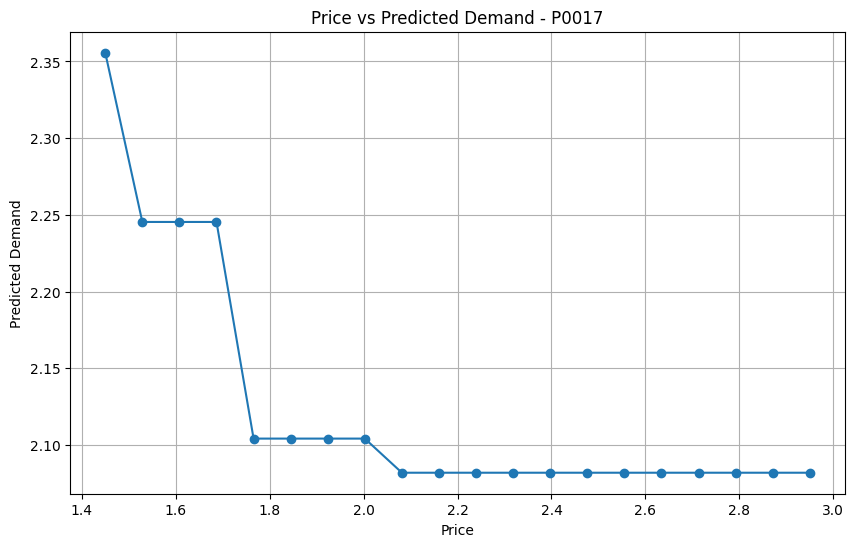

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    simulation["price"],
    simulation["predicted_demand"],
    marker="o"
)

plt.xlabel("Price")
plt.ylabel("Predicted Demand")
plt.title("Price vs Predicted Demand - P0017")

plt.grid(True)
plt.show()

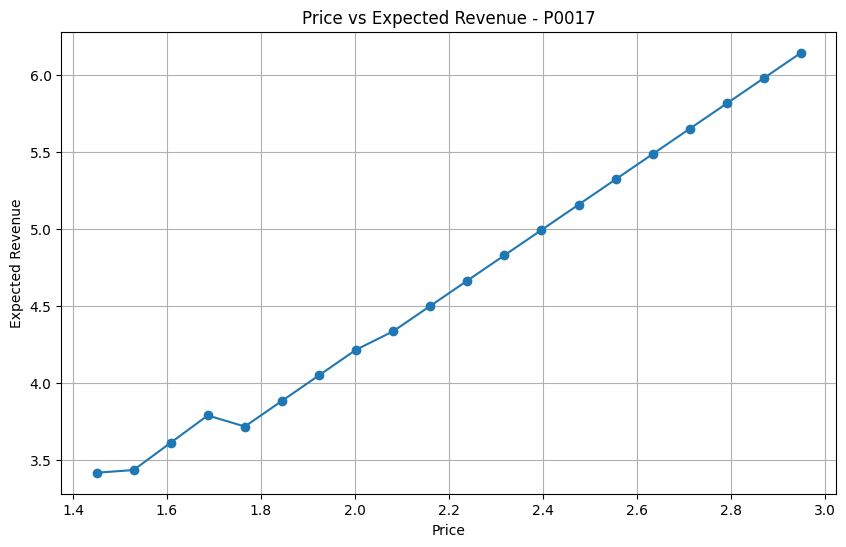

In [79]:
plt.figure(figsize=(10, 6))

plt.plot(
    simulation["price"],
    simulation["expected_revenue"],
    marker="o"
)

plt.xlabel("Price")
plt.ylabel("Expected Revenue")
plt.title("Price vs Expected Revenue - P0017")

plt.grid(True)
plt.show()

## 26. Next Steps

- Extend the multi-product optimization loop to the full product catalog
- Add features that may improve Stage 2 R² (e.g. `price_relative_to_product_avg`, rolling sales averages)
- If cost data becomes available, extend the revenue-optimization step to true profit optimization
- Build a summary dashboard of recommended prices and expected revenue lift per product
